# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import os
import math
import re
import time

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

# Try/Except block to decide which version of seaborn to use based on the matplotlib version installed. This is necessary because the version of seaborn (0.11.1) the TripleTen platform uses is not compatible with matplotlib 3.10.0 which is the version installed on my local machine. However, the seaborn version (0.13.2) that is installed on my local machine is not compatible with matplotlib 3.3.4 which is the version installed on the TripleTen platform. Therefore, this block will try the latest version of seaborn first, and if it throws an `OSError`, it will fall back to the older version of seaborn. 

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:
# self-detecting path of the dataset 
tripleten_path = '/datasets/imdb_reviews.tsv'

local_path = '/Users/georgeknight/Library/Mobile Documents/com~apple~CloudDocs/Career Folder/TripleTen/TripleTen_Projects/Sprint 14 - ML for Texts/dataset/imdb_reviews.tsv'

# check if the path exists, if not, use the local path
if os.path.exists(tripleten_path):
    dataset_path = tripleten_path
else:
    dataset_path = local_path

# read the dataset
df_reviews = pd.read_csv(dataset_path, sep='\t', dtype={'votes': 'Int64'})
corpus = df_reviews['review']

In [5]:
df_reviews.shape

(47331, 17)

In [6]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [7]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [8]:
df_reviews.duplicated().sum()

0

In [9]:
print(df_reviews['end_year'].dtype)
print(df_reviews['end_year'].unique()[:5])

object
['\\N' '1999' '2008' '2005' '1987']


In [10]:
pd.crosstab(df_reviews['sp'], df_reviews['pos'])

pos,0,1
sp,,
neg,23715,0
pos,0,23616


In [11]:
print(df_reviews['runtime_minutes'].dtype)
print(df_reviews['runtime_minutes'].unique()[:10])
print((df_reviews['runtime_minutes'] == '\\N').sum())

object
['121' '25' '88' '85' '90' '113' '96' '99' '43' '82']
488


After review, the columns `'end_year'` and `'runtime_minutes'` both contain literal '\n' strings from IMBD's export convention rather than proper null values. Neither column is used in the modeling or EDA, so no cleaning action was taken.

In [12]:
df_reviews[df_reviews['average_rating'].isna()]

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
22280,tt0192317,movie,Mila Ass Painting,Mila Ass Painting,1998,\N,\N,0,\N,NaN,<NA>,"This is a truly great film, with excellent dir...",9,pos,1,test,3231
22281,tt0192317,movie,Mila Ass Painting,Mila Ass Painting,1998,\N,\N,0,\N,NaN,<NA>,"A film is beyond all expectations, an excellen...",10,pos,1,test,3232


`'average_rating'` and `'votes'` each contain 2 missing values (same rows). Niether column is used in modeling or EDA, so no imputation or removal was taken.

## EDA

Let's check the number of movies and reviews over years.

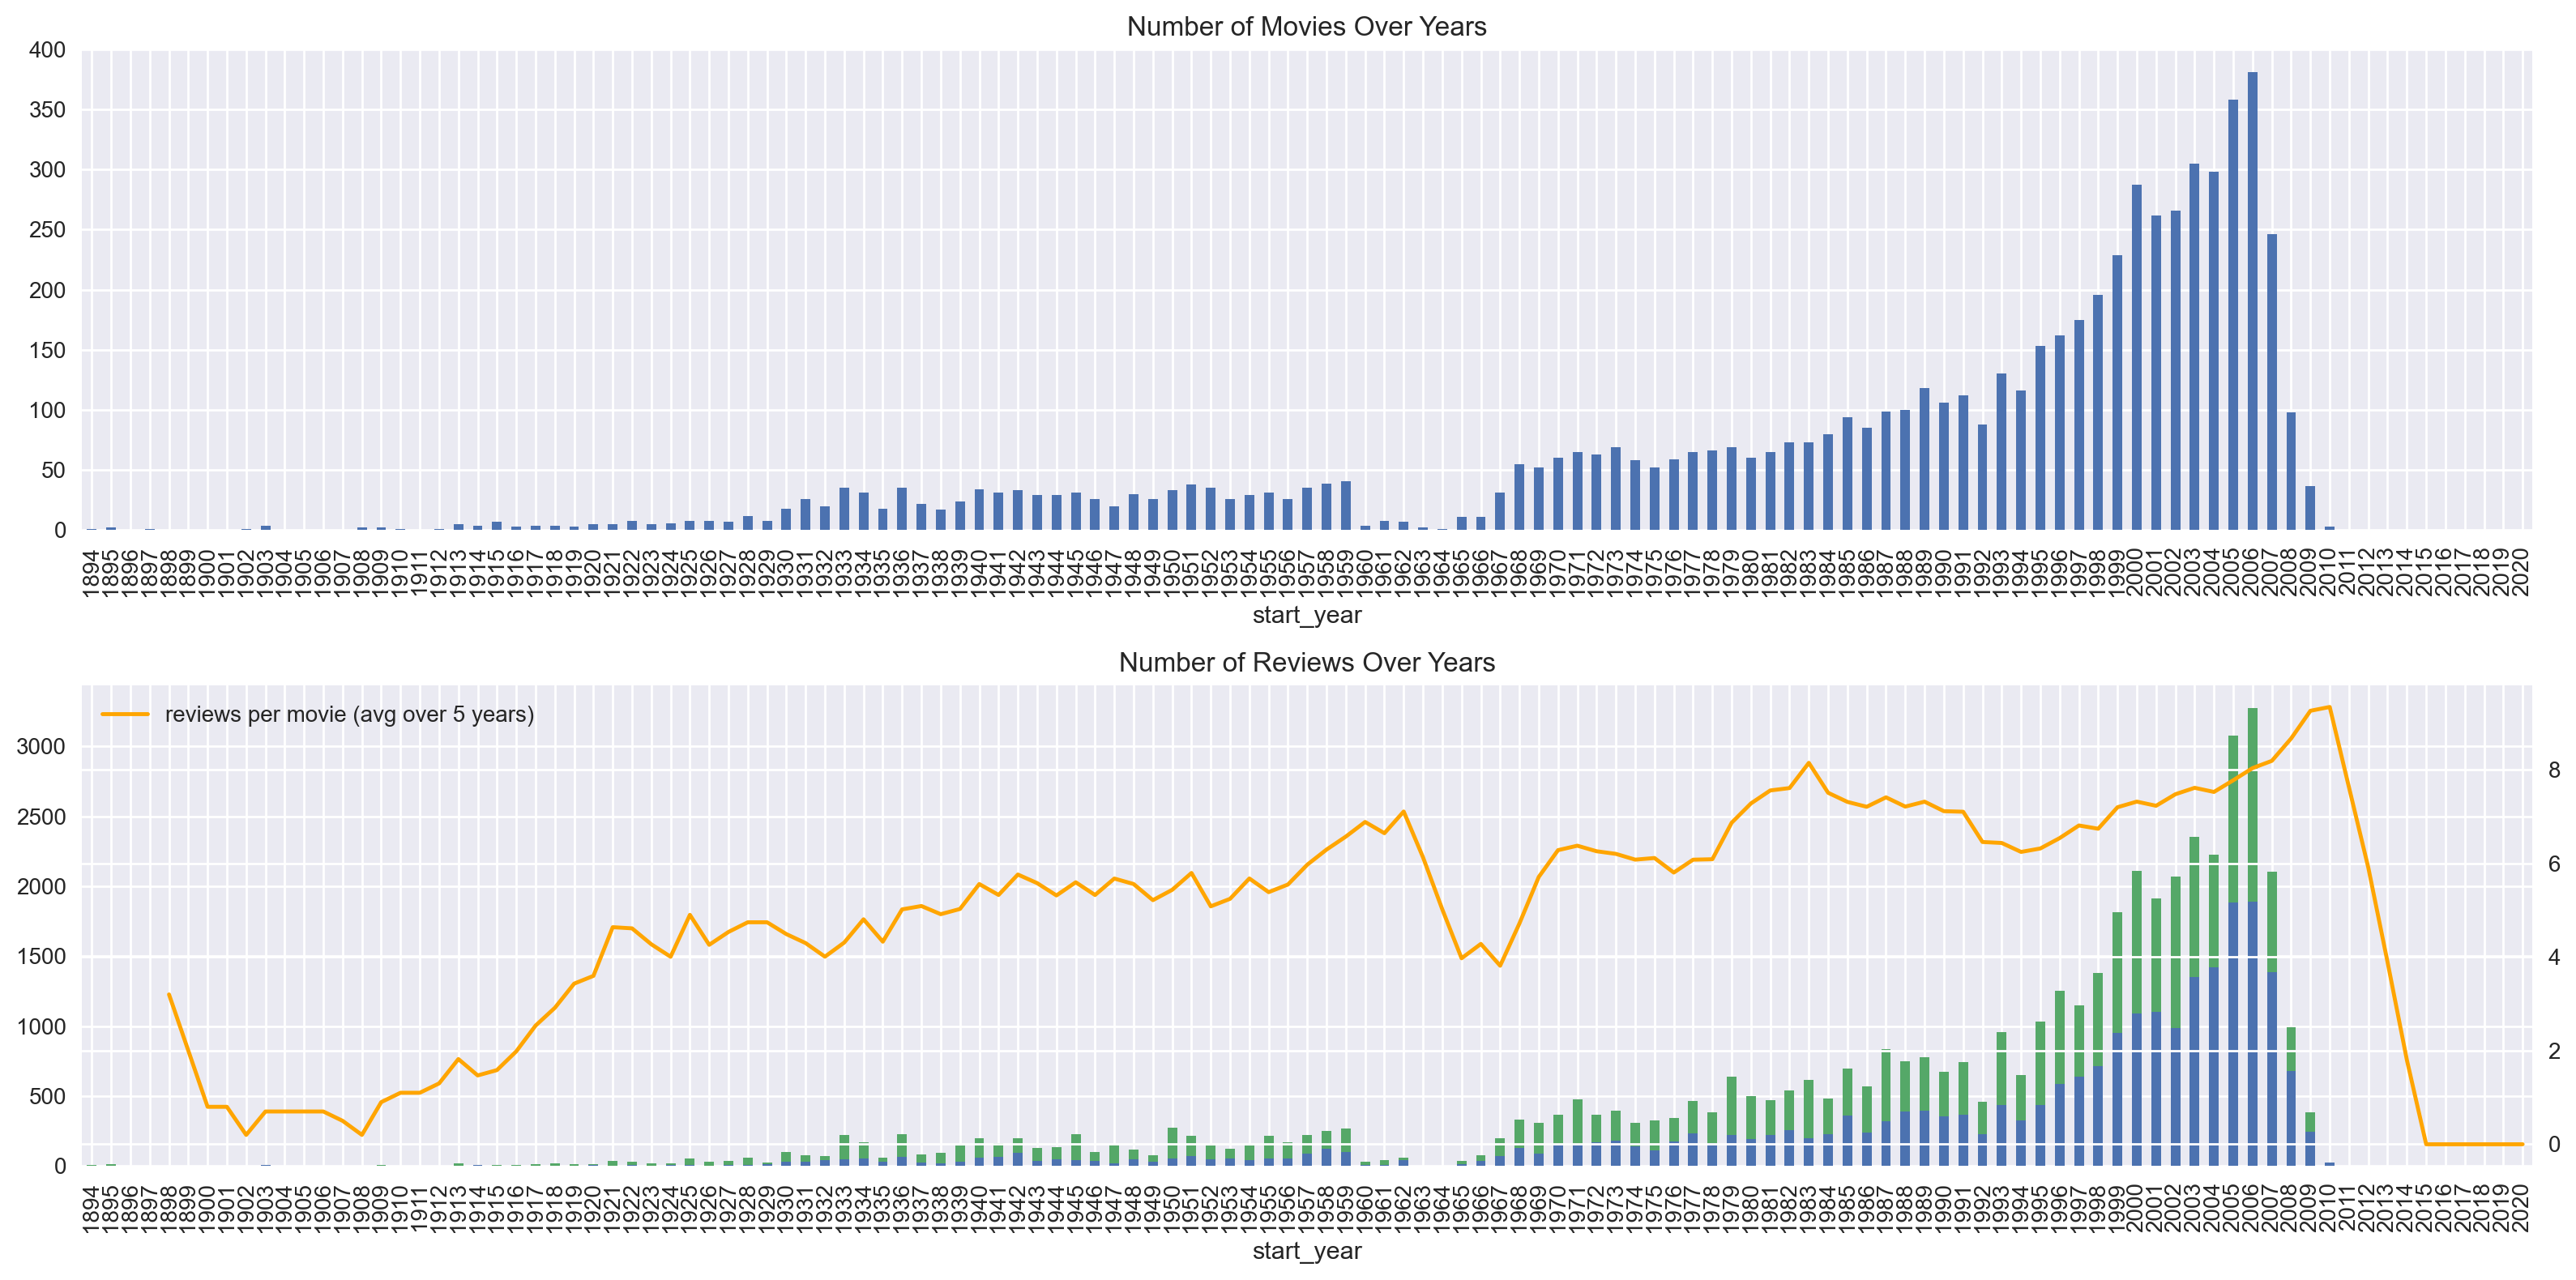

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

plt.show()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

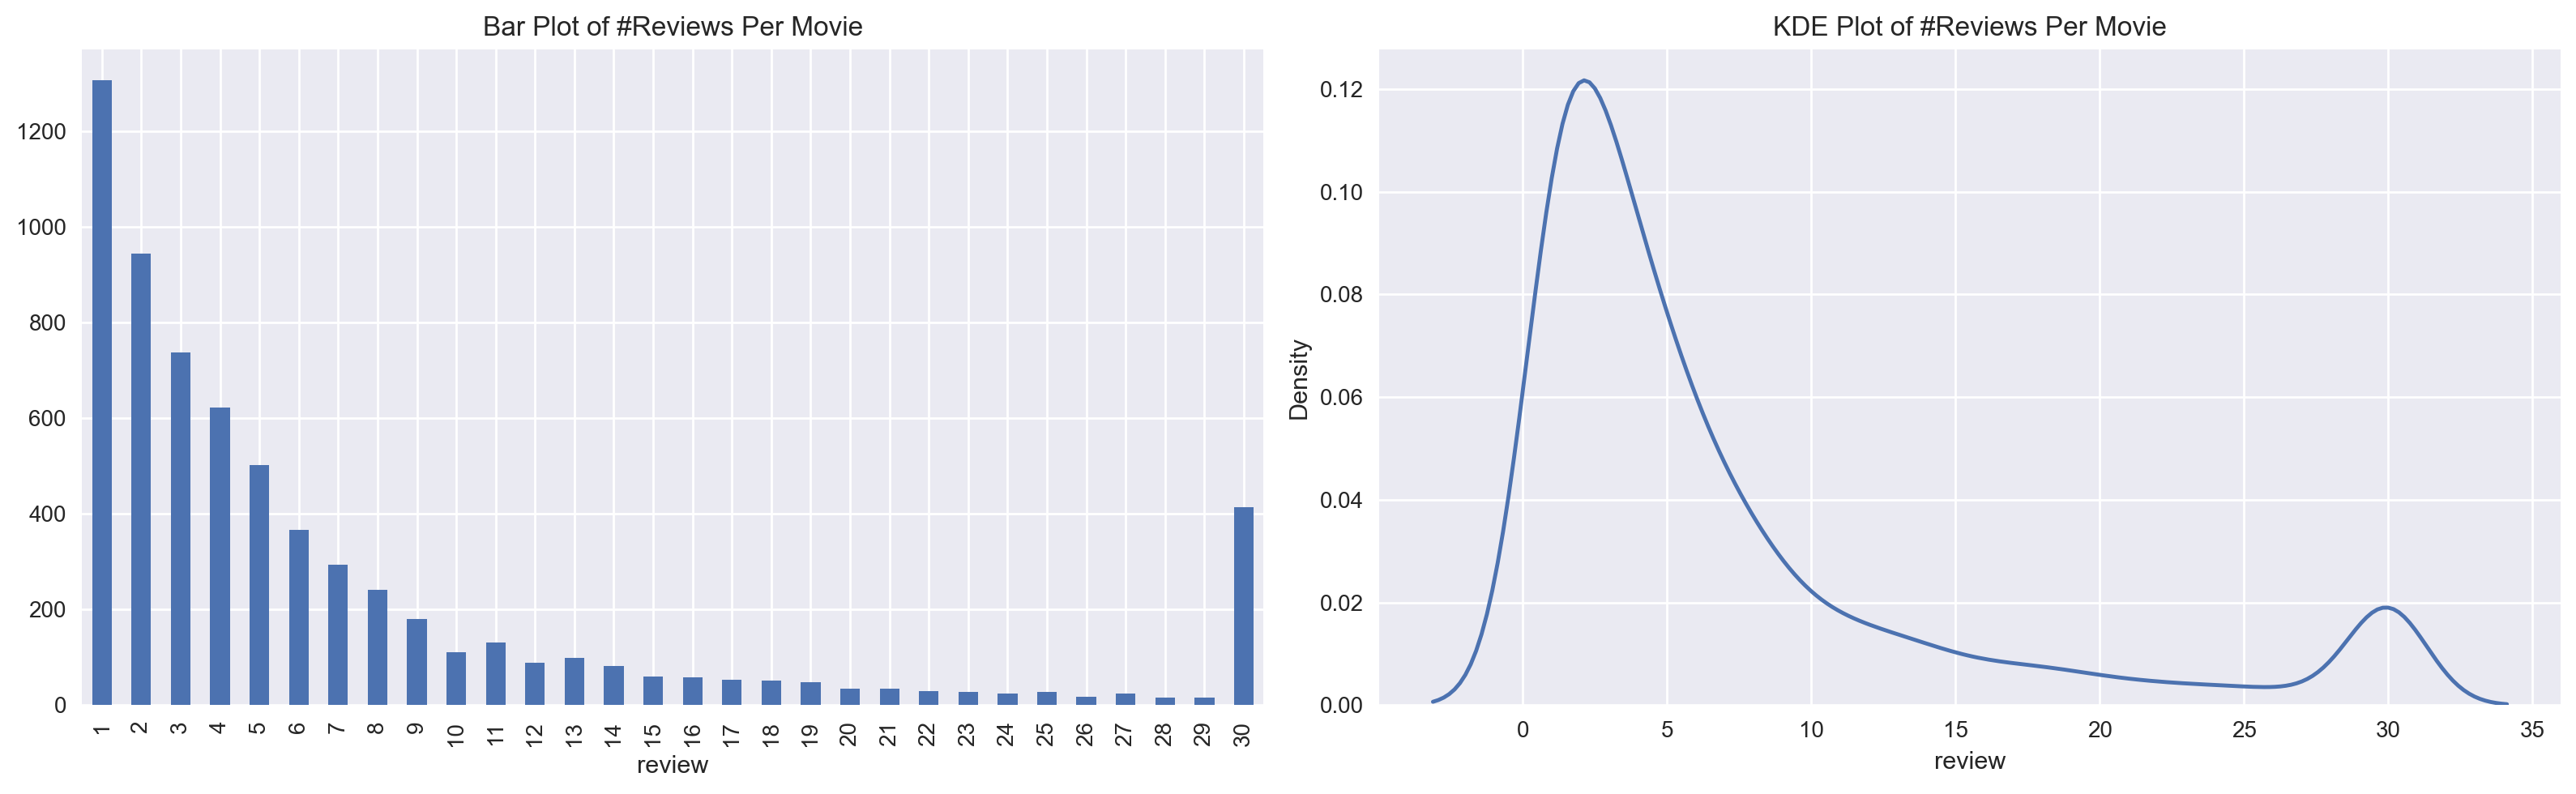

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

plt.show()

In [15]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

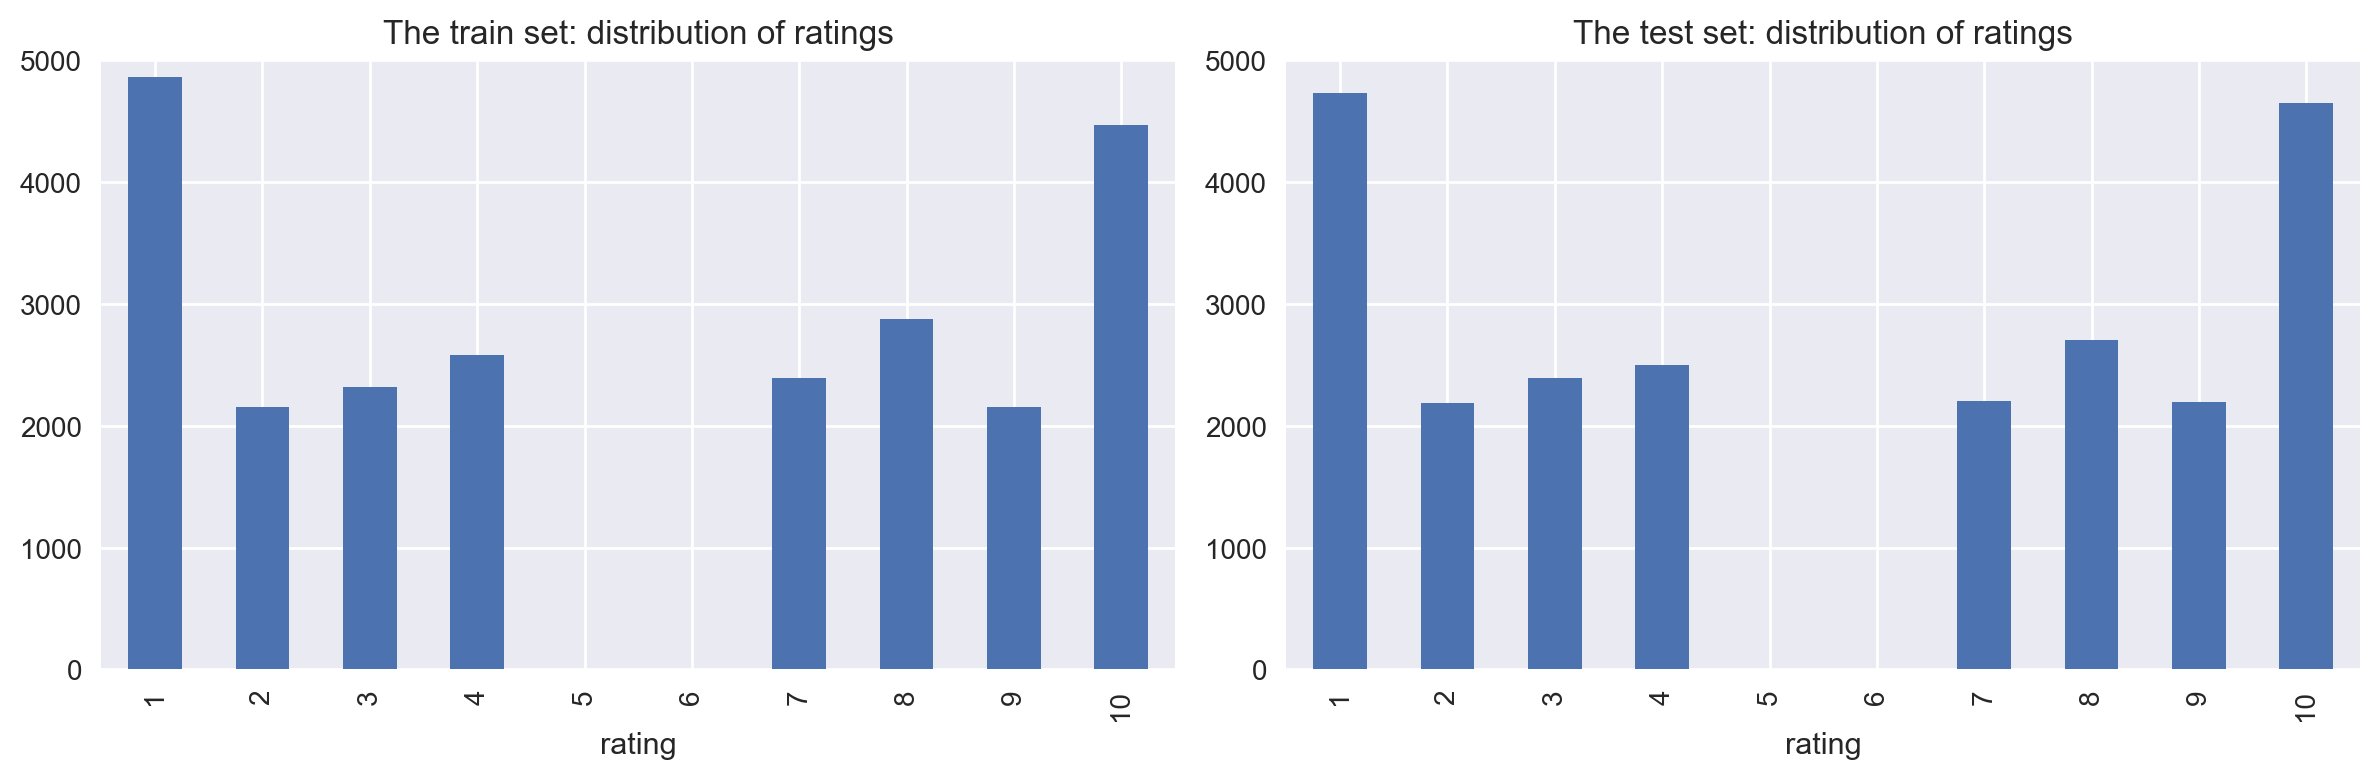

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

plt.show()

Distribution of negative and positive reviews over the years for two parts of the dataset

/var/folders/_x/tfl05v0s1r1dk5r_vn08z5zr0000gn/T/ipykernel_85605/2451702969.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/var/folders/_x/tfl05v0s1r1dk5r_vn08z5zr0000gn/T/ipykernel_85605/2451702969.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/var/folders/_x/tfl05v0s1r1dk5r_vn08z5zr0000gn/T/ipykernel_85605/2451702969.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/var/folders/_x/tfl05v0s1r1dk5r_vn08z5zr0000gn/T/ip

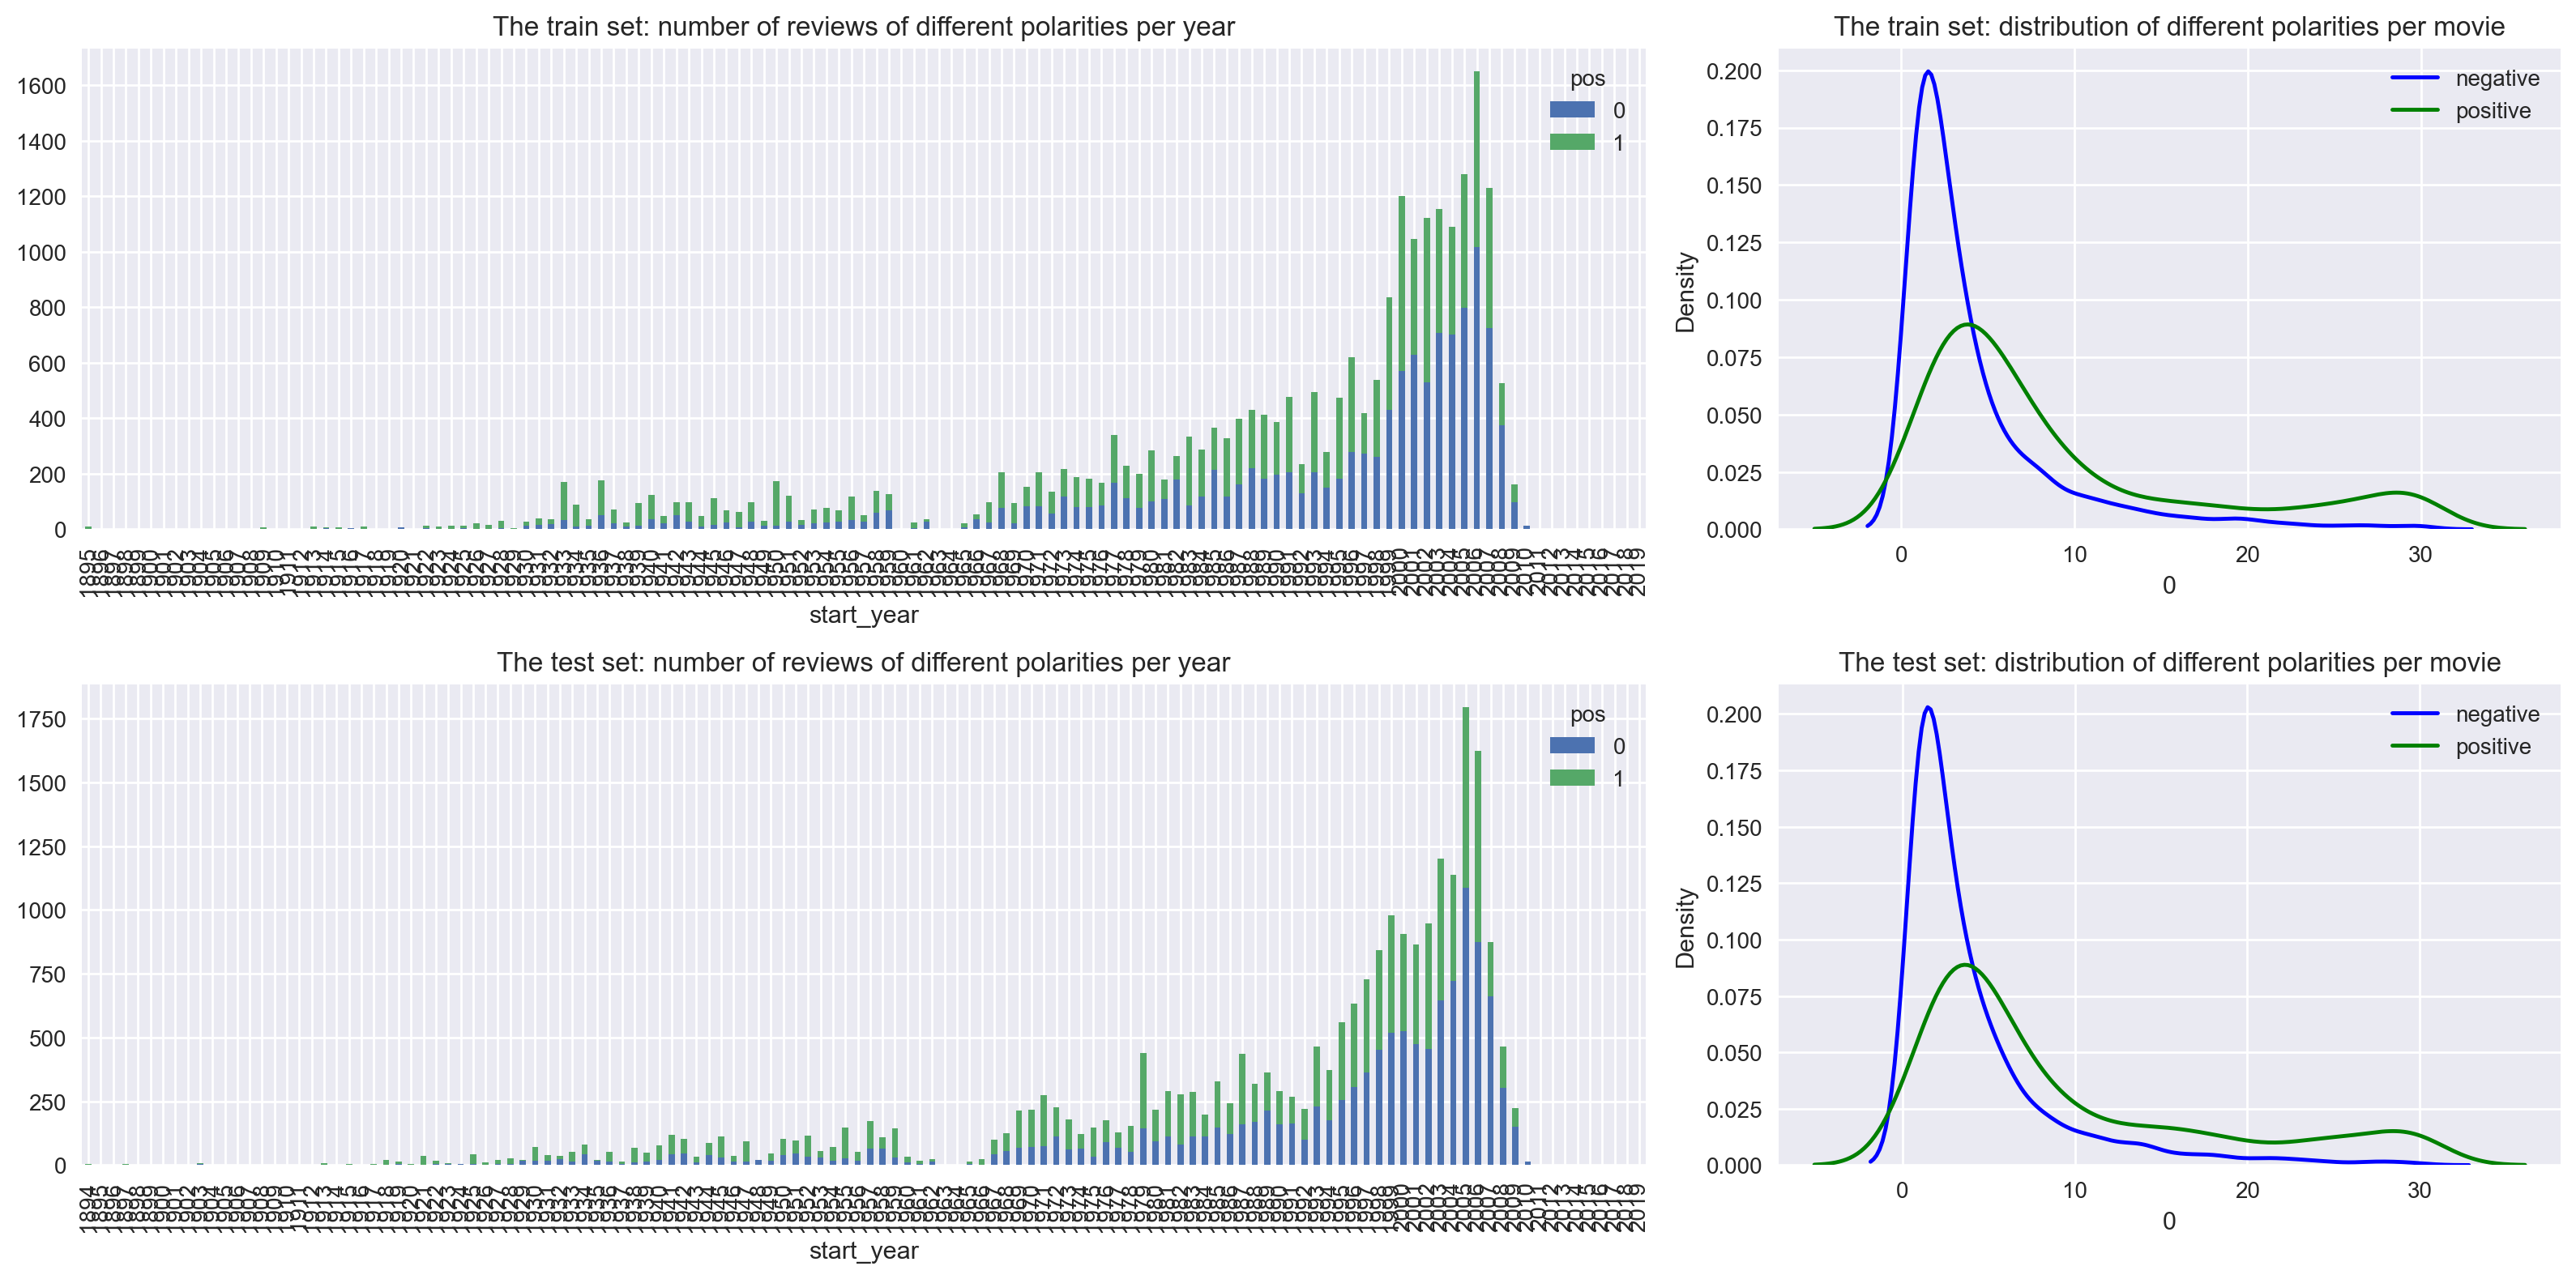

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

plt.show()

### EDA Conclusions

The dataset is effectively balanced at 50.1% negative ratings to 49.9% positive ratings. The balanced dataset leads to a near-mirrored distribution of the ratings across the training and test sets. This leads me to believe the training and test sets were intentionally structured this way to achieve this exact split. This split shows that the ambiguous sentiment that comes with the ratings of 5 and 6 was deliberately excluded and removed by design, which will make the classification task cleaner. Finally, the data also shows that there is a dramatic sentiment shift Post-2000...which is explained by the internet democratization broadening the reviewer pool.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [18]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return df_eval_stats

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [19]:
""" # test to verify that normalization of the review text is working correctly
sample = df_reviews['review'].iloc[0]
print("BEFORE:", sample[:100])
print("AFTER:", re.sub(r'[^a-zA-Z\s]', '', sample.lower())[:100]) """

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/_x/tfl05v0s1r1dk5r_vn08z5zr0000gn/T/ipykernel_85605/1554636756.py:1: SyntaxWarning: invalid escape sequence '\s'
  """ # test to verify that normalization of the review text is working correctly


' # test to verify that normalization of the review text is working correctly\nsample = df_reviews[\'review\'].iloc[0]\nprint("BEFORE:", sample[:100])\nprint("AFTER:", re.sub(r\'[^a-zA-Z\\s]\', \'\', sample.lower())[:100]) '

In [20]:
df_reviews['review_norm'] = df_reviews['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x.lower()))

df_reviews['review_norm'].head()

0    the pakage implies that warren beatty and gold...
1    how the hell did they get this made presenting...
2    there is no real story the film seems more lik...
3    um  a serious film about troubled teens in sin...
4    im totally agree with garryjohal from singapor...
Name: review_norm, dtype: object

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [21]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

print(df_reviews_train.columns.tolist())

(23796, 18)
(23535, 18)
['tconst', 'title_type', 'primary_title', 'original_title', 'start_year', 'end_year', 'runtime_minutes', 'is_adult', 'genres', 'average_rating', 'votes', 'review', 'rating', 'sp', 'pos', 'ds_part', 'idx', 'review_norm']


## Working with models

In [22]:
RND = 42

results = []

### Model 0 - Constant

In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
model_0 = DummyClassifier(strategy='stratified', random_state=RND)

# Start Training Timer
start_time = time.time()

model_0.fit(df_reviews_train['review_norm'], train_target)

# Stop Training Timer
train_time = round(time.time() - start_time, 4)

# Start Prediction Timer
start_time = time.time()
model_0.predict(df_reviews_test['review_norm'])
predict_time = round(time.time() - start_time, 4)

df_model_0_eval_stats = evaluate_model(model_0, df_reviews_train['review_norm'], train_target, df_reviews_test['review_norm'], test_target)



eval_dict = df_model_0_eval_stats.to_dict()

flat_metrics = {f"{split}_{metric}": value
                for split, metrics in eval_dict.items()
                for metric, value in metrics.items()}

# Storing results in list of dictioanries for later use
model_entry = {
    'model': 'Model 0: Dummy Classifier',
    'preprocess_time': None,
    'train_time': train_time,
    'predict_time': predict_time,
    **flat_metrics
}

results.append(model_entry)

print(results)

          train  test
Accuracy    0.5   0.5
F1          0.5   0.5
APS         0.5   0.5
ROC AUC     0.5   0.5
[{'model': 'Model 0: Dummy Classifier', 'preprocess_time': None, 'train_time': 0.0011, 'predict_time': 0.0025, 'train_Accuracy': 0.5, 'train_F1': 0.5, 'train_APS': 0.5, 'train_ROC AUC': 0.5, 'test_Accuracy': 0.5, 'test_F1': 0.5, 'test_APS': 0.5, 'test_ROC AUC': 0.5}]


#### Model 0

Model 0 establishes a baseline F1 of 0.50 - consistent with random prediction on a balanced dataset. All subsequent models must beat this convincingly, with a project target of F1 >= 0.85.

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [25]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/georgeknight/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
# Step 1: Build the TF-IDF vectorizer on the training text, with stopwords in
tf_idf_vect = TfidfVectorizer(stop_words='english')

# Step 2: Transform train and test text into feature matrices
tf_idf_matrix_train = tf_idf_vect.fit_transform(df_reviews_train['review_norm'])
tf_idf_matrix_test = tf_idf_vect.transform(df_reviews_test['review_norm'])

# Step 3: Instantiate and fit Logistic Regression model
model_1 = LogisticRegression(solver='lbfgs', random_state=RND, max_iter=1000)

# Training Timer
start_time = time.time()
model_1.fit(tf_idf_matrix_train, train_target)
train_time = round(time.time() - start_time, 4)

# Prediction Timer
start_time = time.time()
model_1.predict(tf_idf_matrix_test)
predict_time = round(time.time() - start_time, 4)

In [27]:
# Step 4: Call 'evaluate_model' function
df_model_1_eval_stats = evaluate_model(model_1, tf_idf_matrix_train, train_target, tf_idf_matrix_test, test_target)

eval_dict = df_model_1_eval_stats.to_dict()

flat_metrics = {f"{split}_{metric}": value
                for split, metrics in eval_dict.items()
                for metric, value in metrics.items()}

# Storing results in list of dictioanries for later use
model_entry = {
    'model': 'Model 1: Logistic Regression',
    'preprocess_time': None,
    'train_time': train_time,
    'predict_time': predict_time,
    **flat_metrics
}

results.append(model_entry)

print(results)

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95
[{'model': 'Model 0: Dummy Classifier', 'preprocess_time': None, 'train_time': 0.0011, 'predict_time': 0.0025, 'train_Accuracy': 0.5, 'train_F1': 0.5, 'train_APS': 0.5, 'train_ROC AUC': 0.5, 'test_Accuracy': 0.5, 'test_F1': 0.5, 'test_APS': 0.5, 'test_ROC AUC': 0.5}, {'model': 'Model 1: Logistic Regression', 'preprocess_time': None, 'train_time': 0.3338, 'predict_time': 0.0025, 'train_Accuracy': 0.94, 'train_F1': 0.94, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.88, 'test_F1': 0.88, 'test_APS': 0.95, 'test_ROC AUC': 0.95}]


#### Model 1 - Conclusions

After running Model 1 using NLTK, TF-IDF, and LogisticRegression I find the model did quite well. Per the specifications for this project, the minimum F1 score should be equal to or greater than 0.85. As you can see above, this model obtained an F1 score of 0.88 on the test data.

As you can also see there is a gap between the F1 score the model received on the training dataset over what it received on the test dataset, with a gap of 0.06. However, this gap tells us that the model truly learned the patterns within the text that generalized well between the training and test datasets. Yes, there was more than likely some memorization of the training text; however, the amount of memorization is not enough to hurt the performance on any new data this model was to receive.

This model also did considerably better than the baseline Model 0 - Dummy Classification Model. The increase in F1 score by 0.38 tells us that the model actually learned quite a bit from the training set and wasn't just guessing like it was in the DummyClassification model.

### Model 2 - NLTK, TF-IDF and MultinomialNB

In [28]:
from sklearn.naive_bayes import MultinomialNB

In [29]:
# Step 1: Preprocessing has already been accomplished in Model 1, so I am skipping that step here and will use the same TF-IDF vectorizer with stopwords in English.

# Step 2: Transform train and test text into feature matrices was also accomplished in Model 1, so I will use the same feature matrices here.

# Step 3: Instatiate and fit Multinomial Naive Bayes model
model_2 = MultinomialNB(alpha=1.0)

# Training Timer
start_time = time.time()
model_2.fit(tf_idf_matrix_train, train_target)
train_time = round(time.time() - start_time, 4)

# Prediction Timer
start_time = time.time()
model_2.predict(tf_idf_matrix_test)
predict_time = round(time.time() - start_time, 4)

In [30]:
# Step 4: Call 'evaluate_model' function
df_model_2_eval_stats = evaluate_model(model_2, tf_idf_matrix_train, train_target, tf_idf_matrix_test, test_target)

eval_dict = df_model_2_eval_stats.to_dict()

flat_metrics = {f"{split}_{metric}": value
                for split, metrics in eval_dict.items()
                for metric, value in metrics.items()}

# Storing results in list of dictioanries for later use
model_entry = {
    'model': 'Model 2: Multinomial Naive Bayes',
    'preprocess_time': None,
    'train_time': train_time,
    'predict_time': predict_time,
    **flat_metrics
}

results.append(model_entry)

print(results)

          train  test
Accuracy   0.92  0.83
F1         0.92  0.82
APS        0.98  0.91
ROC AUC    0.98  0.91
[{'model': 'Model 0: Dummy Classifier', 'preprocess_time': None, 'train_time': 0.0011, 'predict_time': 0.0025, 'train_Accuracy': 0.5, 'train_F1': 0.5, 'train_APS': 0.5, 'train_ROC AUC': 0.5, 'test_Accuracy': 0.5, 'test_F1': 0.5, 'test_APS': 0.5, 'test_ROC AUC': 0.5}, {'model': 'Model 1: Logistic Regression', 'preprocess_time': None, 'train_time': 0.3338, 'predict_time': 0.0025, 'train_Accuracy': 0.94, 'train_F1': 0.94, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.88, 'test_F1': 0.88, 'test_APS': 0.95, 'test_ROC AUC': 0.95}, {'model': 'Model 2: Multinomial Naive Bayes', 'preprocess_time': None, 'train_time': 0.0092, 'predict_time': 0.0107, 'train_Accuracy': 0.92, 'train_F1': 0.92, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.83, 'test_F1': 0.82, 'test_APS': 0.91, 'test_ROC AUC': 0.91}]


#### Model 2 Conclusion

Running Model 2 using NLTK, TF-IDF and MultinomialNB it is clear that this model did not meet the minimum F1 threshold of 0.85 with an F1 score of 0.82.

Analyzing this models performance, it is easy to see the model is roughly 6 times faster than the Logistic Regression model during the training portion; however, it was 9 times slower during the prediction portion of the model evaluation, which was unexpected to say the least.

Compared to the Logistic Regression model the MultinomialNB model also produced a slightly larger overfitting gap; however, it is still within a healthy margin and wouldn't indicate any issues with the models performance.

After careful analysis, I can not recommend this model strictly because it did not meet the minimum F1 threshold of 0.85. Furthermore, this model illustrates that sometimes speed and accuracy go hand in hand. If the goal is to be faster, then you also need to understand there could potentially be a trade off with accuracy...and vice versa.

### Model 3 - spaCy, TF-IDF and LR

In [31]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [32]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [33]:
# Step 0: Apply the 'text_preprocessing_3' function to the training and test datasets
model_3_preprocess_start_time = time.time()
model_3_preprocessed_train = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)
model_3_preprocessed_test = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)
model_3_preprocess_time = round(time.time() - model_3_preprocess_start_time, 4)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

In [34]:
# Step 1: Build the TF-IDF vectorizer on the training text, without stopwords included
tf_idf_vect_3 = TfidfVectorizer(stop_words=None)

# Step 2: Transform 'model_3_preprocessed' train and test datasets into feature matrices
tf_idf_matrix_train_3 = tf_idf_vect_3.fit_transform(model_3_preprocessed_train)
tf_idf_matrix_test_3 = tf_idf_vect_3.transform(model_3_preprocessed_test)

# Step 3: Instatiate and fit Logistic Regression model
model_3 = LogisticRegression(solver='lbfgs', random_state=RND, max_iter=1000)

# Training Timer
model_3_train_start_time = time.time()
model_3.fit(tf_idf_matrix_train_3, train_target)
model_3_train_time = round(time.time() - model_3_train_start_time, 4)

# Prediction Timer
model_3_predict_start_time = time.time()
model_3.predict(tf_idf_matrix_test_3)
model_3_predict_time = round(time.time() - model_3_predict_start_time, 4)

In [35]:
# Step 4: Call 'evaluate_model' function
df_model_3_eval_stats = evaluate_model(model_3, tf_idf_matrix_train_3, train_target, tf_idf_matrix_test_3, test_target)

eval_dict = df_model_3_eval_stats.to_dict()

flat_metrics = {f"{split}_{metric}": value
                for split, metrics in eval_dict.items()
                for metric, value in metrics.items()}

# Storing results in list of dictioanries for later use
model_entry = {
    'model': 'Model 3: spaCy Logistic Regression',
    'preprocess_time': model_3_preprocess_time,
    'train_time': model_3_train_time,
    'predict_time': model_3_predict_time,
    **flat_metrics
}

results.append(model_entry)

print(results)

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95
[{'model': 'Model 0: Dummy Classifier', 'preprocess_time': None, 'train_time': 0.0011, 'predict_time': 0.0025, 'train_Accuracy': 0.5, 'train_F1': 0.5, 'train_APS': 0.5, 'train_ROC AUC': 0.5, 'test_Accuracy': 0.5, 'test_F1': 0.5, 'test_APS': 0.5, 'test_ROC AUC': 0.5}, {'model': 'Model 1: Logistic Regression', 'preprocess_time': None, 'train_time': 0.3338, 'predict_time': 0.0025, 'train_Accuracy': 0.94, 'train_F1': 0.94, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.88, 'test_F1': 0.88, 'test_APS': 0.95, 'test_ROC AUC': 0.95}, {'model': 'Model 2: Multinomial Naive Bayes', 'preprocess_time': None, 'train_time': 0.0092, 'predict_time': 0.0107, 'train_Accuracy': 0.92, 'train_F1': 0.92, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.83, 'test_F1': 0.82, 'test_APS': 0.91, 'test_ROC AUC': 0.91}, {'model': 'Model 3: spaCy Logistic Regression', 'preprocess_ti

#### Model 3 Conclusion

After running Model 3 using spaCy, TF-IDF, and LogisticRegression I find the model did quite well. Per the specifications for this project, the minimum F1 score should be equal to or greater than 0.85. As you can see above, this model obtained an F1 score of 0.88 on the test data.

As you can see Model 3 did slightly better than Model 1 when we look at the overfitting issue. If you recall Model 1 had a train/test gap of 0.06, where Model 3 only has a gap of 0.05. This means even with the exact same test performance, Model 3 was slightly better at generalizing and finding the patterns in the text than Model 1.

However, here is the crux of the analysis between Model 1 and Model 3, "Was the extra computational cost and time needed for Model 3's preprocessing step truly worth it?" My conclusion is "NO". I base this on the fact that the preprocessing step added an extra 12 minutes and 23.5 seconds to this model's run time, yet it yielded the exact same F1 score as Model 1 with only a slight improvement on overfitting.

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [36]:
from lightgbm import LGBMClassifier

In [37]:
# Step 1: Build the TF-IDF vectorizer on the training text, without stopwords included
tf_idf_vect_4 = TfidfVectorizer(stop_words=None)

# Step 2: Transform 'model_3_preprocessed' train and test datasets into feature matrices
tf_idf_matrix_train_4 = tf_idf_vect_4.fit_transform(model_3_preprocessed_train)
tf_idf_matrix_test_4 = tf_idf_vect_4.transform(model_3_preprocessed_test)

# Step 3: Instatiate and fit LGBMClassifier model
model_4 = LGBMClassifier(random_state=RND, n_estimators=100, learning_rate=0.1)

# Training Timer
model_4_train_start_time = time.time()
model_4.fit(tf_idf_matrix_train_4, train_target)
model_4_train_time = round(time.time() - model_4_train_start_time, 4)

# Prediction Timer
model_4_predict_start_time = time.time()
model_4.predict(tf_idf_matrix_test_4)
model_4_predict_time = round(time.time() - model_4_predict_start_time, 4)

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.169042 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 472166
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 9447
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


In [38]:
# Step 4: Call 'evaluate_model' function
df_model_4_eval_stats = evaluate_model(model_4, tf_idf_matrix_train_4, train_target, tf_idf_matrix_test_4, test_target)

eval_dict = df_model_4_eval_stats.to_dict()

flat_metrics = {f"{split}_{metric}": value
                for split, metrics in eval_dict.items()
                for metric, value in metrics.items()}

# Storing results in list of dictioanries for later use
model_entry = {
    'model': 'Model 4: spaCy LGBMClassifier',
    'preprocess_time': model_3_preprocess_time,
    'train_time': model_4_train_time,
    'predict_time': model_4_predict_time,
    **flat_metrics
}

results.append(model_entry)

print(results)

          train  test
Accuracy   0.92  0.86
F1         0.92  0.86
APS        0.98  0.93
ROC AUC    0.98  0.94
[{'model': 'Model 0: Dummy Classifier', 'preprocess_time': None, 'train_time': 0.0011, 'predict_time': 0.0025, 'train_Accuracy': 0.5, 'train_F1': 0.5, 'train_APS': 0.5, 'train_ROC AUC': 0.5, 'test_Accuracy': 0.5, 'test_F1': 0.5, 'test_APS': 0.5, 'test_ROC AUC': 0.5}, {'model': 'Model 1: Logistic Regression', 'preprocess_time': None, 'train_time': 0.3338, 'predict_time': 0.0025, 'train_Accuracy': 0.94, 'train_F1': 0.94, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.88, 'test_F1': 0.88, 'test_APS': 0.95, 'test_ROC AUC': 0.95}, {'model': 'Model 2: Multinomial Naive Bayes', 'preprocess_time': None, 'train_time': 0.0092, 'predict_time': 0.0107, 'train_Accuracy': 0.92, 'train_F1': 0.92, 'train_APS': 0.98, 'train_ROC AUC': 0.98, 'test_Accuracy': 0.83, 'test_F1': 0.82, 'test_APS': 0.91, 'test_ROC AUC': 0.91}, {'model': 'Model 3: spaCy Logistic Regression', 'preprocess_ti

#### Model 4 Conclusions

As you can see Model 4 - LGBM Classifier using spaCy preprocessing did pass the minimum F1 threshold...barely with a 0.86. The train/test split gap is again within acceptable limits at 0.06. 

However, the biggest issue is the speed of the model. Model 1's training time is 0.4286 seconds, Model 3's training time is 0.4859 seconds, but Model 4's training time is 
5.6423 seconds. This is between 11.6 times and 13.2 times slower than models 1 and 3 respectively. The prediction times were even slower at 23.8 times and 12.6 times slower than models 1 and 3 respectively.

The question then is "Why did the LightGBM Classifier model using spaCy preprocessed features underperform against the Logistic Regression models using TF-IDF features?" That comes down to a fairly simple equation **high dimensionality + sparsity = slow, inefficient tree building with marginal gains per split**. However, the Logistic Regression model doesn't search splits, it simply multiplies each feature by its weight and then sums everything up. So for the sparse features that are basically zeros...the multiplication leaves them zero and therefore they have no impact on the final sum. The other difference between these two different types of models is the way each type of model looks at the features. The LightGBM Classifier (and other tree-based models) builds the decision trees sequentially with each split correcting the errors of the previous one. With tens of thousands of features coming from the 47,000 reviews the tree-based models have to look at all the features at each split. Yet the Logistic Regression doesn't have to do any splits, it just assigns a weight to every feature simultaneously. This makes these types of models far faster than the tree-based models.

Based on all this information, taking into account the training and prediction times I would not recommend the use of LightGBM Classifier or any other tree-based models for this type of project. Yes, the model can be tuned to reach the minimum threshold; however, the sacrifice of computational cost doesn't make it a viable candidate.

###  Model 9 - BERT

ERT embeddings were considered for this project; however, given that the project 
requires a minimum of three models and Models 1, 3, and 4 all exceed the F1 ≥ 0.85 
threshold, the significant computational cost of BERT (several hours on CPU) was 
determined to not be justified. The three implemented models provide sufficient 
coverage of the project requirements.

## My Reviews

In [39]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    "Even though I am not a big fan of Tom Cruise, I felt that the latest Top Gun movie was very well done. The combat scenes were amazingly put together and you can really tell they are in fighter jets pulling the \"Gs\" in those turns. Of course there were some unrealistic aspects like an F-14 against fifth generation fighters. However, overall I love this movie.",
    "This is one of those movies I could watch over and over again and never get tired of. The tension between the native Navee and the Human settlers reminds me so much of the wild west here in America. But this movie illustrates that everyone can overcome their prejudices if they just try and see the world through the eyes of their so called enemy. Highly recommend to anyone.",
    "By far one of the worst movies I have ever seen. The plot was impossible to follow and the ending was absolutely horrible with zero resolution to the story. The only reason I kept watching was because I kept telling myself it has to get better…but it never did.",
    "This was the worst movie I have seen to date in 2024, and I am not just saying that because I am not into romantic movies. This movie was seriously lacking a plot line, character development, and any resemblance of finality.",
    "This movie was amazing with it’s special effects and breath taking visuals of far off worlds; but the trek to get to these worlds was what most people believe space travel to be like…a long boring slog to get there. What made it even more of a struggle was the one crew member that was awake and all they could do is send transmissions back to earth which took over 24 hours to reach earth and then another 24 hours back…and talk with the on board artificial intelligence.",
    "I have mixed feelings about this one. The best part of the movie is definitely the cast. Leonardo DiCaprio and the other actors deliver excellent performances, and the visual effects are impressive and creative. However, despite its quality, I found the film quite boring and too long. The pacing felt very slow, and some scenes were overly complicated, making it hard to stay fully engaged. While I appreciate the originality of the concept and Christopher Nolan’s ambition, the story sometimes felt more exhausting than exciting. Overall, Inception is technically very well made and brilliantly acted, but for me it was too slow and lengthy to truly enjoy. Regardless, Nolan remains one of my favorite directors. If you haven't already, go see Interstellar and The Dark Knight."
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x.lower()))

my_reviews

,review,review_norm
0,"Even though I am not a big fan of Tom Cruise, ...",even though i am not a big fan of tom cruise i...
1,This is one of those movies I could watch over...,this is one of those movies i could watch over...
2,By far one of the worst movies I have ever see...,by far one of the worst movies i have ever see...
3,This was the worst movie I have seen to date i...,this was the worst movie i have seen to date i...
4,This movie was amazing with it’s special effec...,this movie was amazing with its special effect...
5,I have mixed feelings about this one. The best...,i have mixed feelings about this one the best ...


### Model 1

In [40]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tf_idf_vect.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.47:  even though i am not a big fan of tom cruise i felt that the latest top gun movie was very well done
0.85:  this is one of those movies i could watch over and over again and never get tired of the tension bet
0.02:  by far one of the worst movies i have ever seen the plot was impossible to follow and the ending was
0.03:  this was the worst movie i have seen to date in  and i am not just saying that because i am not into
0.34:  this movie was amazing with its special effects and breath taking visuals of far off worlds but the 
0.86:  i have mixed feelings about this one the best part of the movie is definitely the cast leonardo dica


### Model 2

In [41]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tf_idf_vect.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.38:  even though i am not a big fan of tom cruise i felt that the latest top gun movie was very well done
0.76:  this is one of those movies i could watch over and over again and never get tired of the tension bet
0.16:  by far one of the worst movies i have ever seen the plot was impossible to follow and the ending was
0.20:  this was the worst movie i have seen to date in  and i am not just saying that because i am not into
0.36:  this movie was amazing with its special effects and breath taking visuals of far off worlds but the 
0.71:  i have mixed feelings about this one the best part of the movie is definitely the cast leonardo dica


### Model 3

In [42]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tf_idf_vect_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.61:  even though i am not a big fan of tom cruise i felt that the latest top gun movie was very well done
0.79:  this is one of those movies i could watch over and over again and never get tired of the tension bet
0.07:  by far one of the worst movies i have ever seen the plot was impossible to follow and the ending was
0.01:  this was the worst movie i have seen to date in  and i am not just saying that because i am not into
0.26:  this movie was amazing with its special effects and breath taking visuals of far off worlds but the 
0.93:  i have mixed feelings about this one the best part of the movie is definitely the cast leonardo dica


### Model 4

In [43]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tf_idf_vect_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.67:  even though i am not a big fan of tom cruise i felt that the latest top gun movie was very well done
0.93:  this is one of those movies i could watch over and over again and never get tired of the tension bet
0.02:  by far one of the worst movies i have ever seen the plot was impossible to follow and the ending was
0.04:  this was the worst movie i have seen to date in  and i am not just saying that because i am not into
0.38:  this movie was amazing with its special effects and breath taking visuals of far off worlds but the 
0.95:  i have mixed feelings about this one the best part of the movie is definitely the cast leonardo dica


### Model 9

ERT embeddings were considered for this project; however, given that the project 
requires a minimum of three models and Models 1, 3, and 4 all exceed the F1 ≥ 0.85 
threshold, the significant computational cost of BERT (several hours on CPU) was 
determined to not be justified. The three implemented models provide sufficient 
coverage of the project requirements.

## Conclusions

### My Reviews Conclusions

When I compared the 4 model results on my own reviews, an interesting pattern of consistent limitation across all models was revealed. Referencing the ambiguous review for a space movie, all 4 models missed the mark because they took all the words in the review and basically counted the negative and positive words, then added up the totals for each and that was where the sentiment fell...in the negative. However, the other ambiguous review was for the movie Inception. Here the models did the same thing as with the space movie, but the positive sentiment words won out, thus resulting in the model giving it a positive rating. Then the final example was a positive review for the movie Top Gun Maverick. This review started out with the phrase "Even though I am not a big fan of Tom Cruise,...", but what the model saw was the following: 'even', 'though', 'not', 'big', 'fan', 'tom', 'cruise'. Each individual word doesn't convey the sentiment the phrase does. This limitation has the potential to impact the accuracy of how the model rates a movie based on the written review.

In [44]:
# Create a DataFrame from the results list of dictionaries
df_results = pd.DataFrame(results)
df_results['preprocess_time'] = df_results['preprocess_time'].fillna('N/A')
df_results


,model,preprocess_time,train_time,predict_time,train_Accuracy,train_F1,train_APS,train_ROC AUC,test_Accuracy,test_F1,test_APS,test_ROC AUC
0,Model 0: Dummy Classifier,N/A,0.0011,0.0025,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50
1,Model 1: Logistic Regression,N/A,0.3338,0.0025,0.94,0.94,0.98,0.98,0.88,0.88,0.95,0.95
2,Model 2: Multinomial Naive Bayes,N/A,0.0092,0.0107,0.92,0.92,0.98,0.98,0.83,0.82,0.91,0.91
3,Model 3: spaCy Logistic Regression,743.3744,0.4914,0.0041,0.93,0.93,0.98,0.98,0.88,0.88,0.95,0.95
4,Model 4: spaCy LGBMClassifier,743.3744,4.9641,0.0766,0.92,0.92,0.98,0.98,0.86,0.86,0.93,0.94


### Final Conclusion

Upon final analysis of these 5 models, I would recommend Model 1: Logistic Regression using NLTK and TF-IDF. Of all the models this model was the most accurate and maintained a rapid execution for both the training and the predictions. It also exceeded the F1 score threshold of 0.85 by 0.03 with a 0.88. 

I would not recommend Model 2: Multinomial Naive Bayes using NLTK and TF-IDF. Even though this model was lightning fast on the training it surprisingly came in 9 times slower on the prediction aspect of the model. The speed of this model also cost us accuracy as the model could not meet the minimum F1 score with a 0.82.

The biggest surprise was that the LightGBM Classifier was considerably slower than all the other models even though it is a model that is traditionally built for speed and accuracy. The limitation is that since it is a tree-based model it must look at all of the tens of thousands of features everytime the tree splits.

However, there is a fundamental limitation that all TF-IDF based models had and that was the ability to truly understand the context of the words as they appear in their individual phrases. This was most evident during my test using my own personal movie reviews. These models basically take all the words and put them into a bag of words individually, then they count up and weigh those that are traditionally negative and traditionally positive. Thus losing the true context.

# Checklist

- [x]  Notebook was opened
- [x]  The text data is loaded and pre-processed for vectorization
- [x]  The text data is transformed to vectors
- [x]  Models are trained and tested
- [x]  The metric's threshold is reached
- [x]  All the code cells are arranged in the order of their execution
- [x]  All the code cells can be executed without errors
- [x]  There are conclusions